# Análise no Domínio do Tempo de Sistemas em Tempo Discreto


In [4]:
# Calcular a energia de um sinal E definido por:
# A soma dos quadrados de suas amostras
sinal = [2, 1, 2, 3, 4, 5]
E = 0
for a in sinal:
    E += a**2
print("O valor de E é:", E)

O valor de E é: 59


In [6]:
# sinal = 2(1/2)^n u[n]
n = range(0, 100000)
sinal = [2*(1/2)**i for i in n] 
E = 0
for a in sinal:
    E += a**2
    # print(a, E)    
print("O valor de E é:", E)

O valor de E é: 5.333333333333333


In [7]:
# P = Energia / (2N+1)
P = E / (2*len(sinal) + 1)
print("O valor de P é:", P)

O valor de P é: 2.6666533333999995e-05


In [19]:
import numpy as np
import matplotlib.pyplot as plt

class SinalPDS:
    def __init__(self, n_min: int = -10, n_max: int = 20, taxa_amostragem: float = 100.0):
        """
        Inicializa os eixos temporais para as simulações de PDS.
        
        :param n_min: Índice inicial para sequências discretas.
        :param n_max: Índice final para sequências discretas.
        :param taxa_amostragem: Taxa para sinais contínuos (Hz).
        """
        self.n = np.arange(n_min, n_max + 1)  # Eixo do tempo discreto n
        self.taxa_amostragem = taxa_amostragem
        
        # Atributos que guardarão o sinal atualizado
        self.valores = np.zeros_like(self.n, dtype=float)
        self.tempo_continuo = np.array([])
        self.tipo_sinal = "Nenhum"

    # --- GERADORES DE SINAIS ---

    def gerar_impulso(self, atraso: int = 0):
        """Gera o impulso unitário delta[n - atraso]"""
        self.valores = np.where(self.n == atraso, 1.0, 0.0)
        self.tipo_sinal = f"Impulso Unitário $\delta[n - {atraso}]$"
        return self

    def gerar_degrau(self, atraso: int = 0):
        """Gera o degrau unitário u[n - atraso]"""
        self.valores = np.where(self.n >= atraso, 1.0, 0.0)
        self.tipo_sinal = f"Degrau Unitário $u[n - {atraso}]$"
        return self

    def gerar_senoide(self, freq_hz: float, amplitude: float = 1.0, fase_rad: float = 0.0, duracao_seg: float = 1.0):
        """Gera uma senoide contínua amostrada x(t) = A*sin(2*pi*f*t + fase)"""
        self.tempo_continuo = np.arange(0, duracao_seg, 1.0 / self.taxa_amostragem)
        self.valores = amplitude * np.sin(2 * np.pi * freq_hz * self.tempo_continuo + fase_rad)
        self.tipo_sinal = f"Senoide ({freq_hz} Hz)"
        return self

    def gerar_exponencial(self, a: float, amplitude: float = 1.0, complexa: bool = False):
        """Gera um sinal exponencial x[n] = Amplitude * (a^n)"""
        if complexa:
            # Se 'a' for complexo ou uma frequência angular, gera exponencial complexa
            # Exemplo: a = exp(j * omega) -> amplitude * exp(j * omega * n)
            self.valores = amplitude * np.exp(1j * a * self.n)
            self.tipo_sinal = f"Exponencial Complexa $e^{{j \cdot {a} \cdot n}}$"
        else:
            self.valores = amplitude * (a ** self.n)
            self.tipo_sinal = f"Exponencial Real ${amplitude} \cdot ({a})^n$"
        return self

    # --- MÉTODOS DE PLOTAGEM ---

    def plotar_discreto(self, titulo: str = ""):
        """Plota o sinal no formato clássico de PDS usando stem (ramos)"""
        plt.figure(figsize=(10, 4))
        
        # Verifica se é um sinal complexo (comum em exponenciais e FFT)
        if np.iscomplexobj(self.valores):
            valores_plot = np.abs(self.valores)
            label_y = "Magnitude"
            tit_sufixo = " (Magnitude Complexa)"
        else:
            valores_plot = self.valores
            label_y = "Amplitude $x[n]$"
            tit_sufixo = ""

        # Se houver tempo contínuo associado, usa ele, senão usa o índice n
        if len(self.tempo_continuo) > 0 and len(self.tempo_continuo) == len(self.valores):
            x_eixo = self.tempo_continuo
            label_x = "Tempo (segundos)"
        else:
            x_eixo = self.n
            label_x = "Amostras ($n$)"

        plt.stem(x_eixo, valores_plot, linefmt='C0-', markerfmt='C0o', basefmt='black')
        plt.title(titulo if titulo else f"{self.tipo_sinal}{tit_sufixo}")
        plt.xlabel(label_x)
        plt.ylabel(label_y)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

    def plotar_espectro(self):
        """Calcula e plota o módulo da FFT do sinal atual"""
        valores_reais = np.real(self.valores) if np.iscomplexobj(self.valores) else self.valores
        n_pontos = len(valores_reais)
        
        fft_valores = np.abs(np.fft.fft(valores_reais)) / n_pontos
        frequencias = np.fft.fftfreq(n_pontos, 1 / self.taxa_amostragem)
        
        # Ordena para exibir o gráfico centralizado em 0 ou progressivo
        idx = np.argsort(frequencias)
        
        plt.figure(figsize=(10, 4))
        plt.plot(frequencias[idx], fft_valores[idx], color='purple')
        plt.title(f"Espectro de Frequência - {self.tipo_sinal}")
        plt.xlabel("Frequência (Hz)")
        plt.ylabel("Magnitude")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()


<>:26: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:48: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:48: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:51: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:26: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:48: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:48: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences wil

<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_8100\2484730820.py:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  delta.plotar_discreto(titulo="Impulso Unitário $\delta[n]$")


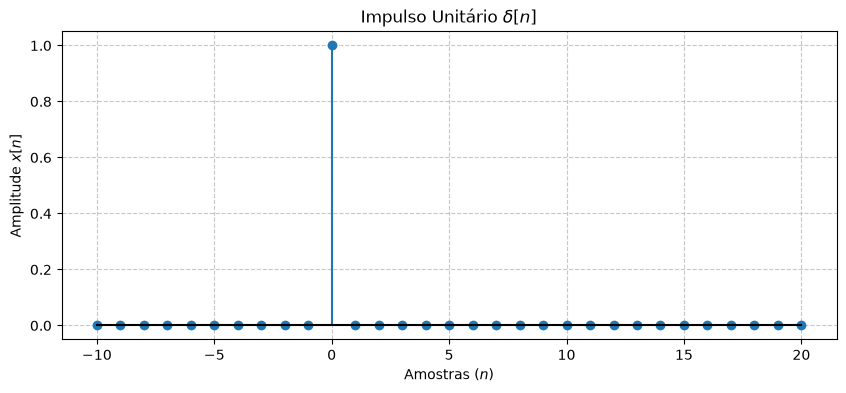

In [20]:
s = SinalPDS()
delta = s.gerar_impulso(atraso=0)
delta.plotar_discreto(titulo="Impulso Unitário $\delta[n]$")    


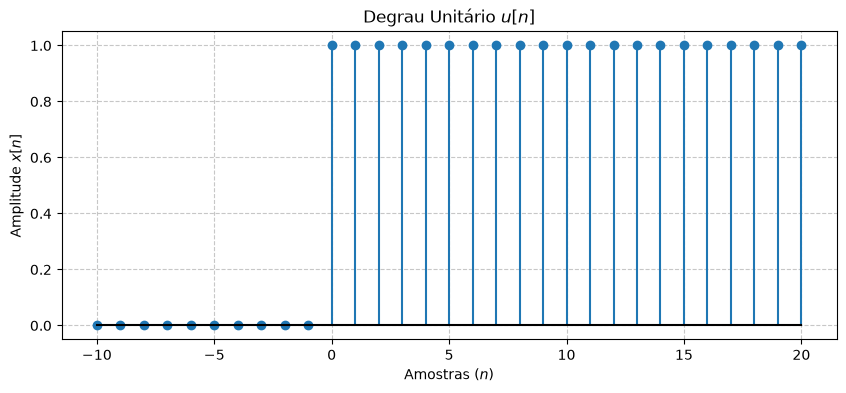

In [21]:
u = s.gerar_degrau(atraso=0)
u.plotar_discreto(titulo="Degrau Unitário $u[n]$")

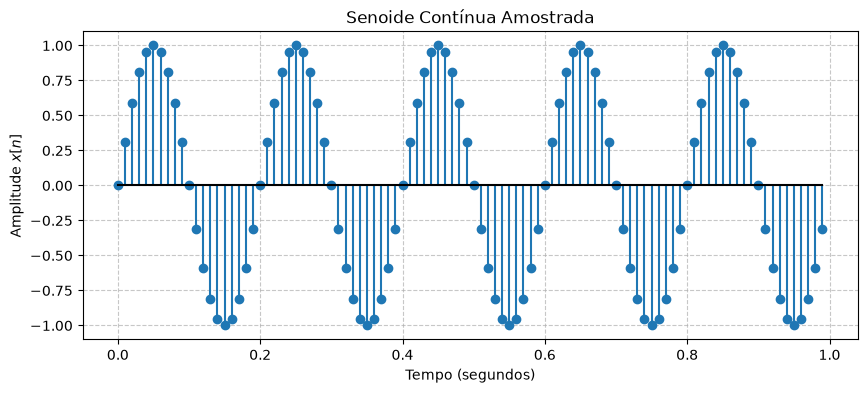

In [22]:
senoide = s.gerar_senoide(freq_hz=5, amplitude=1.0, fase_rad=0.0, duracao_seg=1.0)
senoide.plotar_discreto(titulo="Senoide Contínua Amostrada")

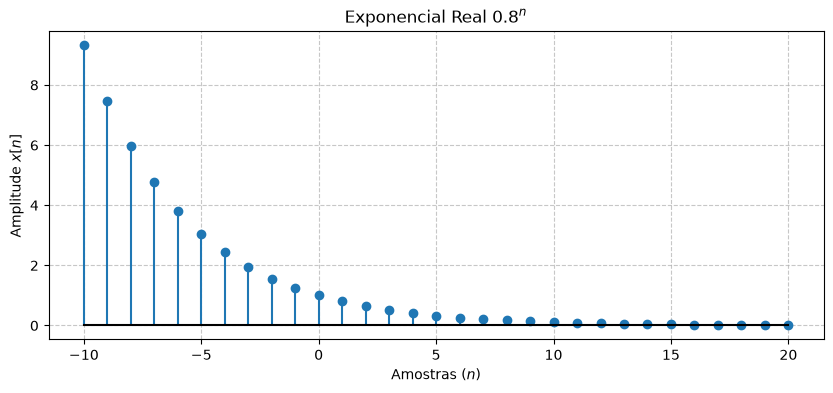

In [23]:
exponencial_real = s.gerar_exponencial(a=0.8, amplitude=1.0, complexa=False)
exponencial_real.plotar_discreto(titulo="Exponencial Real $0.8^n$")

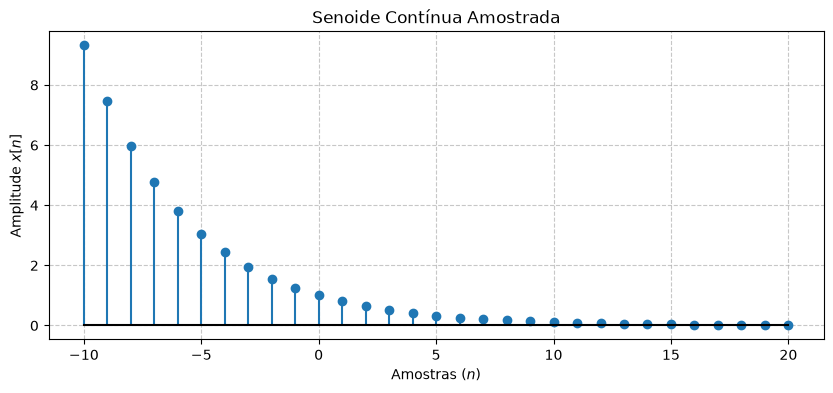

In [24]:
# ver espectro
senoide.plotar_discreto(titulo="Senoide Contínua Amostrada" )


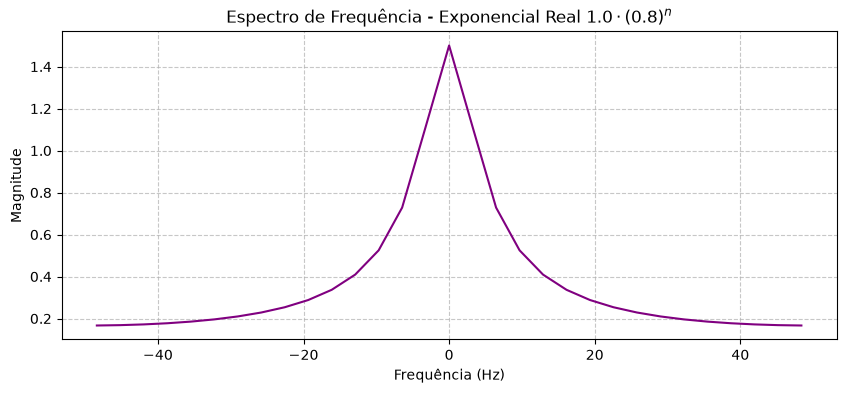

In [25]:
exponencial_real.plotar_espectro() 

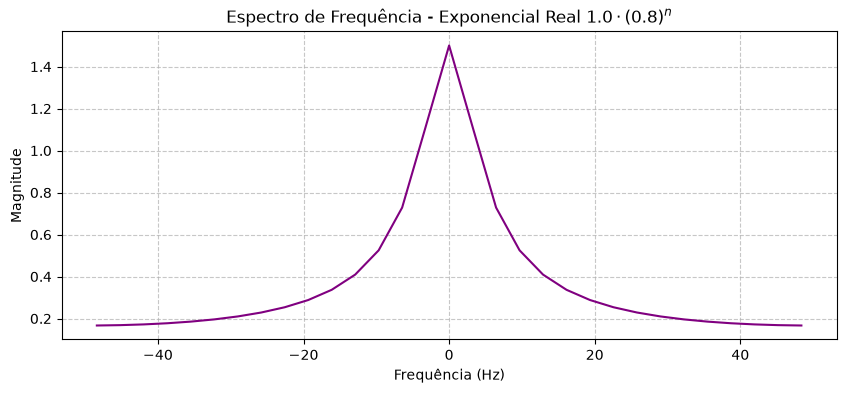

In [26]:
senoide.plotar_espectro()